In [192]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

# Create outputs folder for saving charts (run this notebook from:
# C:\Users\Admin\Downloads\Data Analytics\Seasonal Agriculture Performance)
os.makedirs('outputs', exist_ok=True)

In [193]:
# Load dataset
df = pd.read_csv('cleaned_seasonal_agriculture.csv')
print("Shape:", df.shape)
df.head()

Shape: (4000, 31)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct,Cost_per_Hectare,Is_Loss_Making
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3,-38.47,80494.34,True
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9,-1118.66,75398.32,True
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7,-65.49,64858.02,True
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6,-47.68,65876.44,True
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3,-74.56,80275.30,True


In [194]:
# Structure and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    4000 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              4000 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [195]:
# Summary statistics
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.2600,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.714313,288.427366,80.000,370.4250,581.0000,836.12500,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.9000,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.7750,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.6000,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.2600,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.504525,6.696998,8.000,21.7000,26.4000,31.20000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.5000,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.2000,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.2000,105.1000,123.60000,200.00


In [196]:
# Check missing values, duplicates, and unique category values
print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())
print("\nSeasons:", df['Season'].unique())
print("Crops:", df['Crop'].unique())
print("States:", df['State'].nunique())
print("Irrigation methods:", df['Irrigation_Method'].unique())

Missing values:
 Series([], dtype: int64)

Duplicate rows: 0

Seasons: <StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str
Crops: <StringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str
States: 8
Irrigation methods: <StringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str


In [197]:
# Data cleaning: season-wise median imputation for season-dependent columns
df_clean = df.copy()

for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df_clean[col] = df_clean.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

# Feature engineering
df_clean['Profit_Margin_pct'] = (df_clean['Profit_INR'] / df_clean['Revenue_INR'] * 100).round(2)
df_clean['Cost_per_Hectare'] = (df_clean['Total_Cost_INR'] / df_clean['Farm_Area_Hectares']).round(2)
df_clean['Is_Loss_Making'] = df_clean['Profit_INR'] < 0

print("Remaining nulls:", df_clean.isnull().sum().sum())
df_clean.head()


Remaining nulls: 0


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct,Cost_per_Hectare,Is_Loss_Making
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3,-38.47,80494.34,True
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9,-1118.66,75398.32,True
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7,-65.49,64858.02,True
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6,-47.68,65876.44,True
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3,-74.56,80275.30,True


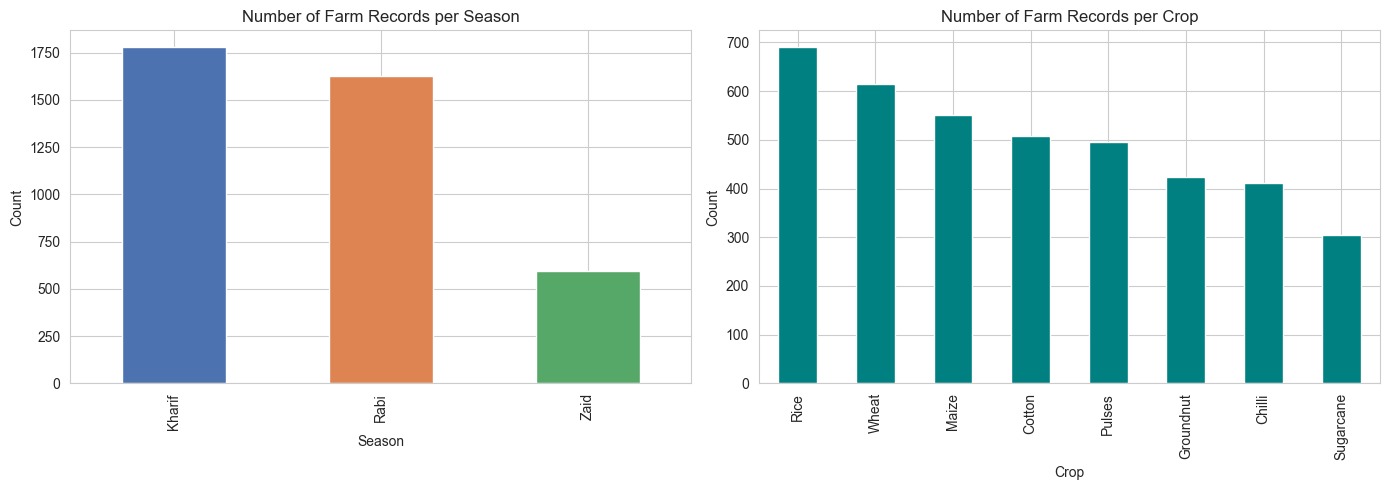

In [198]:
# Distribution of records by season and crop
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_clean['Season'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452','#55A868'])
axes[0].set_title('Number of Farm Records per Season')
axes[0].set_xlabel('Season'); axes[0].set_ylabel('Count')

df_clean['Crop'].value_counts().plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Number of Farm Records per Crop')
axes[1].set_xlabel('Crop'); axes[1].set_ylabel('Count')
plt.tight_layout()
plt.savefig('outputs/01_season_crop_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [199]:
# Average environmental conditions by season
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_Moisture_pct']
season_env = df_clean.groupby('Season')[env_cols].mean().round(2)
season_env

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.11,28.45,71.81,6.79,31.20
Rabi,435.94,23.49,57.89,7.59,24.05
Zaid,299.12,31.04,52.01,8.18,19.17


C:\Users\Admin\AppData\Local\Temp\ipykernel_14012\3142602327.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y=col, ax=ax,
C:\Users\Admin\AppData\Local\Temp\ipykernel_14012\3142602327.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y=col, ax=ax,
C:\Users\Admin\AppData\Local\Temp\ipykernel_14012\3142602327.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y=col, ax=ax,
C:\Users\Admin\AppData\Local\Temp\ipykernel_14012\3142602327.py:4: FutureWarning: 

P

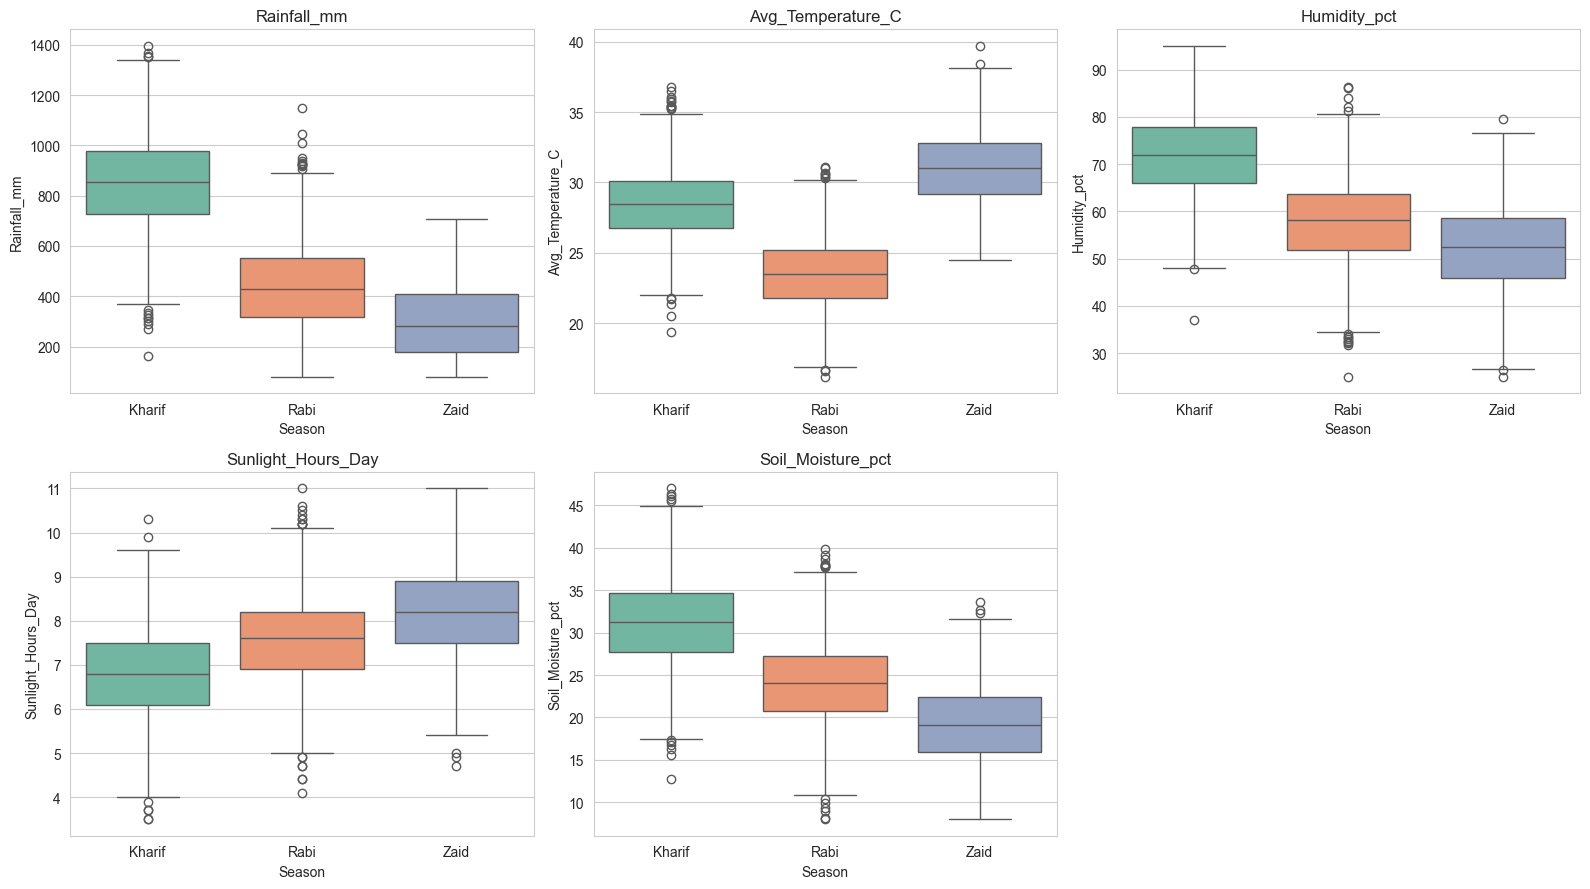

In [200]:
# Boxplots of environmental variables by season
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, env_cols):
    sns.boxplot(data=df_clean, x='Season', y=col, ax=ax,
                order=['Kharif','Rabi','Zaid'], palette='Set2')
    ax.set_title(col)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.savefig('outputs/02_environmental_conditions_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

In [201]:
# Yield and profitability summary by season
perf_summary = df_clean.groupby('Season').agg(
    Avg_Yield_t_ha=('Yield_Tonnes_Ha','mean'),
    Avg_Revenue_INR=('Revenue_INR','mean'),
    Avg_Cost_INR=('Total_Cost_INR','mean'),
    Avg_Profit_INR=('Profit_INR','mean'),
    Loss_Making_Pct=('Is_Loss_Making', lambda x: round(x.mean()*100,1)),
    Avg_Profit_Margin_Pct=('Profit_Margin_pct','mean')
).round(0)
perf_summary

,Avg_Yield_t_ha,Avg_Revenue_INR,Avg_Cost_INR,Avg_Profit_INR,Loss_Making_Pct,Avg_Profit_Margin_Pct
Season,,,,,,
Kharif,6.0,710719.0,531804.0,178915.0,42.0,-39.0
Rabi,5.0,601526.0,513837.0,87689.0,51.0,-44.0
Zaid,5.0,519172.0,543977.0,-24805.0,64.0,-69.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_14012\3895936318.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y='Yield_Tonnes_Ha', order=order, ax=axes[0], palette='Set2', showfliers=False)
C:\Users\Admin\AppData\Local\Temp\ipykernel_14012\3895936318.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y='Profit_INR', order=order, ax=axes[1], palette='Set2', showfliers=False)


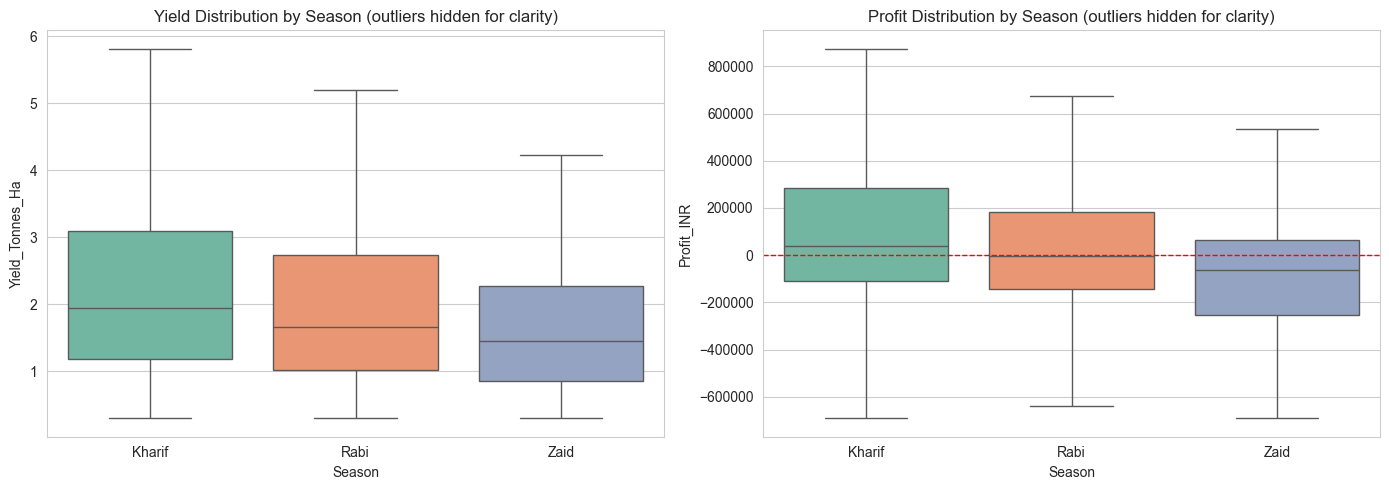

In [202]:
# Yield and profit distribution by season
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = ['Kharif','Rabi','Zaid']
sns.boxplot(data=df_clean, x='Season', y='Yield_Tonnes_Ha', order=order, ax=axes[0], palette='Set2', showfliers=False)
axes[0].set_title('Yield Distribution by Season (outliers hidden for clarity)')

sns.boxplot(data=df_clean, x='Season', y='Profit_INR', order=order, ax=axes[1], palette='Set2', showfliers=False)
axes[1].set_title('Profit Distribution by Season (outliers hidden for clarity)')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('outputs/03_yield_profit_distribution_by_season.png', dpi=150, bbox_inches='tight')
plt.show()


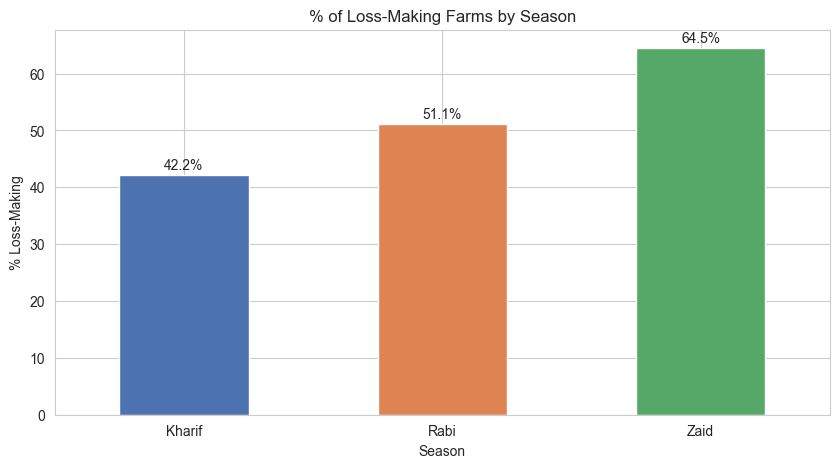

In [203]:
# Percentage of loss-making farms by season
loss_by_season = df_clean.groupby('Season')['Is_Loss_Making'].mean().mul(100).round(1).reindex(order)
loss_by_season.plot(kind='bar', color=['#4C72B0','#DD8452','#55A868'])
plt.title('% of Loss-Making Farms by Season')
plt.ylabel('% Loss-Making')
plt.xticks(rotation=0)
for i, v in enumerate(loss_by_season):
    plt.text(i, v+1, f'{v}%', ha='center')
plt.savefig('outputs/04_loss_making_pct_by_season.png', dpi=150, bbox_inches='tight')
plt.show()


In [204]:
# Average profit by crop and season (pivot table)
crop_season_profit = df_clean.pivot_table(values='Profit_INR', index='Crop', columns='Season', aggfunc='mean').round(0)
crop_season_profit = crop_season_profit[order]
crop_season_profit

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.0,638572.0,448659.0
Cotton,217000.0,107344.0,-53925.0
Groundnut,108265.0,10417.0,-68872.0
Maize,-39333.0,-89133.0,-194049.0
Pulses,43339.0,-14309.0,-139228.0
Rice,-64903.0,-98428.0,-227239.0
Sugarcane,1000791.0,731613.0,583636.0
Wheat,-105872.0,-119955.0,-193209.0


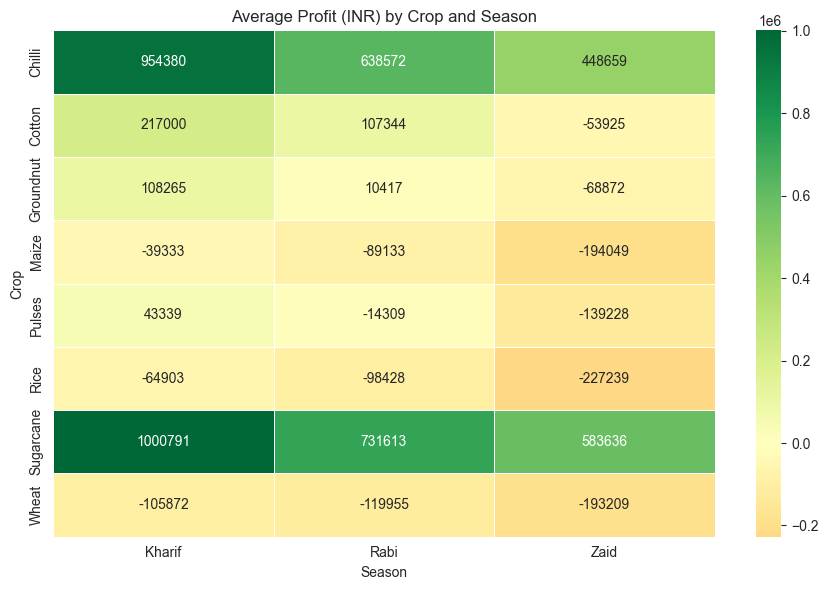

In [205]:
# Heatmap: profit by crop and season
plt.figure(figsize=(9,6))
sns.heatmap(crop_season_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Average Profit (INR) by Crop and Season')
plt.tight_layout()
plt.savefig('outputs/05_profit_by_crop_and_season.png', dpi=150, bbox_inches='tight')
plt.show()

In [206]:
# Water efficiency by irrigation method and season (pivot table)
irrig_season = df_clean.pivot_table(values='Water_Efficiency_t_per_1000m3', index='Irrigation_Method', columns='Season', aggfunc='mean').round(2)
irrig_season = irrig_season[order]
irrig_season

Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,6.80,6.05,5.30
Flood,3.64,3.48,2.73
Rainfed,8.85,6.87,5.48
Sprinkler,4.62,4.64,4.86


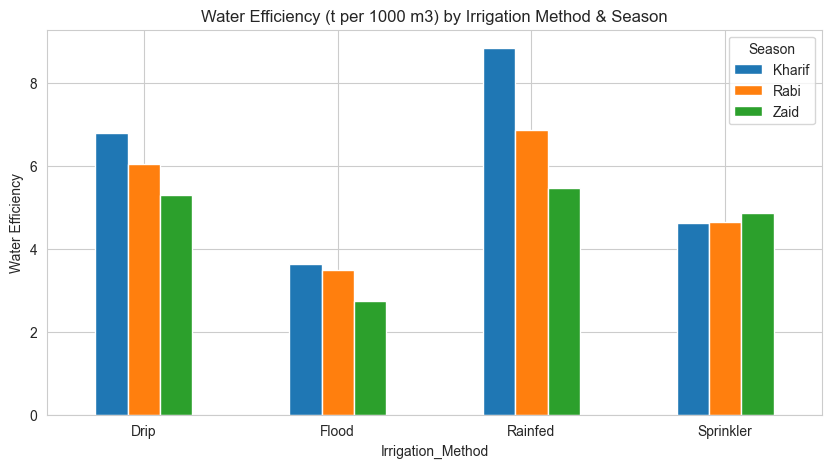

In [207]:
# Bar chart: water efficiency by irrigation method and season
irrig_season.plot(kind='bar', figsize=(10,5))
plt.title('Water Efficiency (t per 1000 m3) by Irrigation Method & Season')
plt.ylabel('Water Efficiency')
plt.xticks(rotation=0)
plt.legend(title='Season')
plt.savefig('outputs/06_water_efficiency_by_irrigation_and_season.png', dpi=150, bbox_inches='tight')
plt.show()


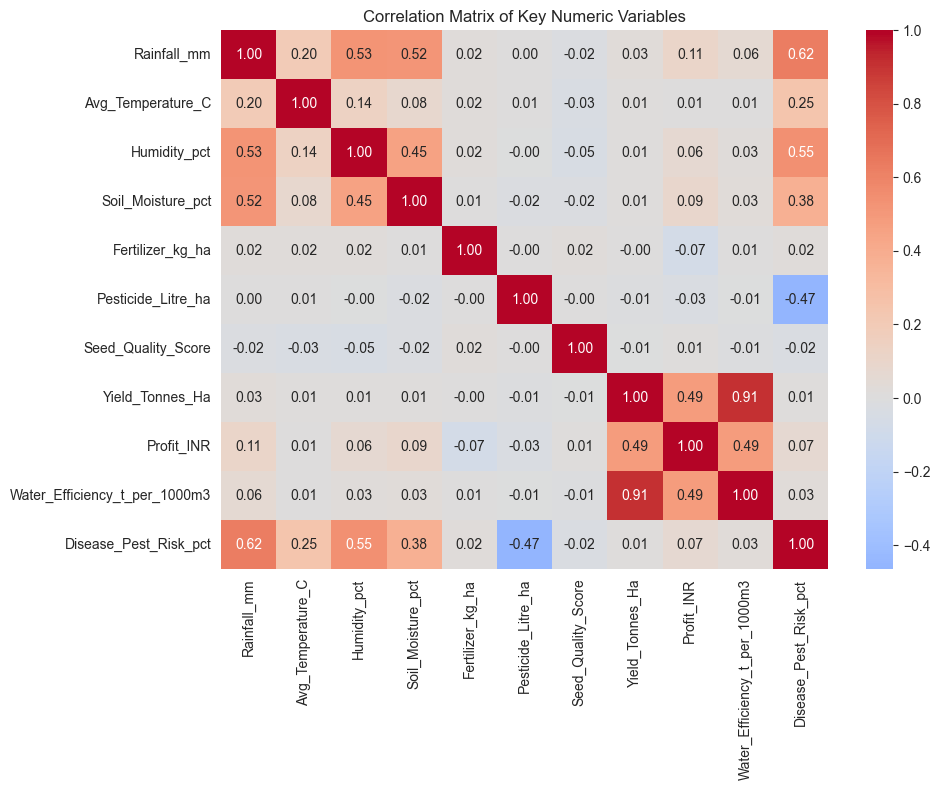

In [208]:
# Correlation matrix of key numeric variables
num_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Soil_Moisture_pct',
            'Fertilizer_kg_ha','Pesticide_Litre_ha','Seed_Quality_Score',
            'Yield_Tonnes_Ha','Profit_INR','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']

plt.figure(figsize=(10,8))
sns.heatmap(df_clean[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Key Numeric Variables')
plt.tight_layout()
plt.savefig('outputs/07_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [209]:
# ANOVA test: does season significantly affect yield?
kharif_yield = df_clean[df_clean['Season']=='Kharif']['Yield_Tonnes_Ha']
rabi_yield = df_clean[df_clean['Season']=='Rabi']['Yield_Tonnes_Ha']
zaid_yield = df_clean[df_clean['Season']=='Zaid']['Yield_Tonnes_Ha']

f_stat, p_value = stats.f_oneway(kharif_yield, rabi_yield, zaid_yield)
print(f"ANOVA F-statistic: {f_stat:.3f}, p-value: {p_value:.5f}")
if p_value < 0.05:
    print("=> Statistically significant difference in yield across seasons (reject H0).")
else:
    print("=> No statistically significant difference in yield across seasons.")


ANOVA F-statistic: 1.554, p-value: 0.21156
=> No statistically significant difference in yield across seasons.


In [210]:
# Average profit by state and season (pivot table)
state_season_profit = df_clean.pivot_table(values='Profit_INR', index='State', columns='Season', aggfunc='mean').round(0)
state_season_profit = state_season_profit[order]
state_season_profit


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169316.0,26316.0,-84085.0
Gujarat,217051.0,82846.0,-106930.0
Karnataka,201226.0,70953.0,23311.0
Madhya Pradesh,134242.0,61576.0,210.0
Maharashtra,168801.0,159582.0,-40598.0
Punjab,133779.0,169295.0,62110.0
Tamil Nadu,211304.0,70457.0,-15175.0
Telangana,199668.0,62825.0,-34621.0


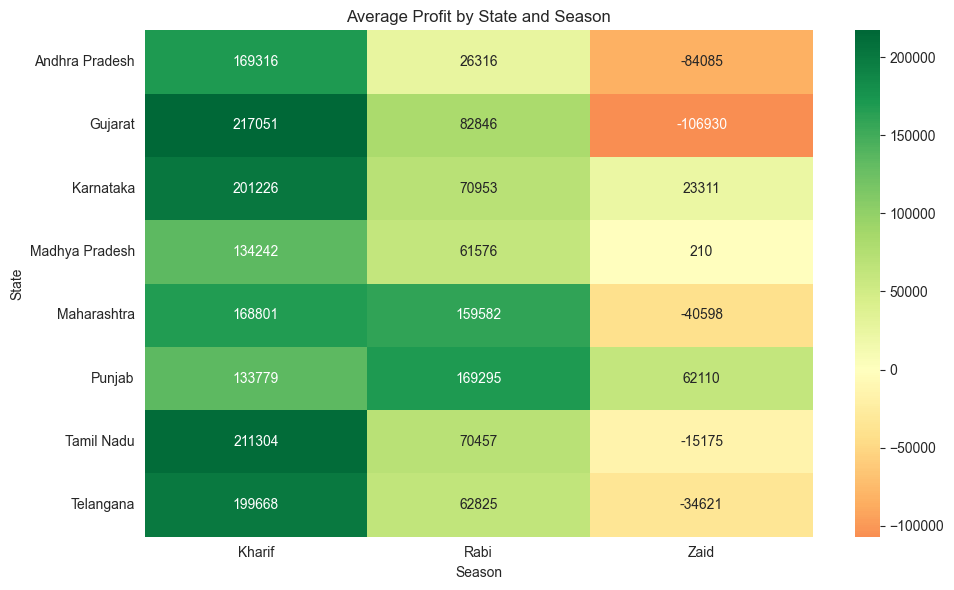

In [211]:
# Heatmap: profit by state and season
plt.figure(figsize=(10,6))
sns.heatmap(state_season_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Average Profit by State and Season')
plt.tight_layout()
plt.savefig('outputs/08_profit_by_state_and_season.png', dpi=150, bbox_inches='tight')
plt.show()
